In [1]:
import pandas as pd
import numpy as np
from math import factorial
from scipy.integrate import simpson
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('simulated_call_centre.csv')

In [3]:
df

,call_id,date,daily_caller,call_started,call_answered,call_ended,wait_length,service_length,meets_standard
0,1,1/1/2021,1,8:00:00 AM,8:00:00 AM,8:14:22 AM,0,863,True
1,2,1/1/2021,2,8:02:42 AM,8:02:42 AM,8:07:31 AM,0,289,True
2,3,1/1/2021,3,8:08:24 AM,8:08:24 AM,8:10:13 AM,0,108,True
3,4,1/1/2021,4,8:09:37 AM,8:09:37 AM,8:13:45 AM,0,247,True
4,5,1/1/2021,5,8:11:10 AM,8:11:10 AM,8:15:28 AM,0,258,True
...,...,...,...,...,...,...,...,...,...
51703,51704,12/31/2021,267,5:50:10 PM,5:50:10 PM,5:57:26 PM,0,436,True
51704,51705,12/31/2021,268,5:50:31 PM,5:50:31 PM,5:54:55 PM,0,265,True
51705,51706,12/31/2021,269,5:51:29 PM,5:51:29 PM,5:54:26 PM,0,177,True
51706,51707,12/31/2021,270,5:53:10 PM,5:54:26 PM,5:57:50 PM,76,204,False


In [4]:
df['call_started'] = pd.to_datetime(df['date'].astype(str) + ' ' + df['call_started'].astype(str))
df['call_answered'] = pd.to_datetime(df['date'].astype(str) + ' ' + df['call_answered'].astype(str))
df['call_ended'] = pd.to_datetime(df['date'].astype(str) + ' ' + df['call_ended'].astype(str))

In [5]:
df_time = df.set_index('call_started')
calls_per_hour = df_time.resample('1h').size()
peak_hour_start = calls_per_hour.idxmax()
peak_hour_calls = calls_per_hour.max()
peak_hour_end = peak_hour_start + pd.Timedelta(hours=1) - pd.Timedelta(seconds=1)

In [6]:
print(peak_hour_calls)

43


In [7]:
df_peak = df[(df['call_started'] >= peak_hour_start) & (df['call_started'] <= peak_hour_end)].copy()

In [8]:
df_peak

,call_id,date,daily_caller,call_started,call_answered,call_ended,wait_length,service_length,meets_standard
46027,46028,12/3/2021,24,2021-12-03 09:01:42,2021-12-03 09:01:42,2021-12-03 09:04:56,0,195,True
46028,46029,12/3/2021,25,2021-12-03 09:02:43,2021-12-03 09:02:43,2021-12-03 09:05:14,0,151,True
46029,46030,12/3/2021,26,2021-12-03 09:03:59,2021-12-03 09:03:59,2021-12-03 09:07:20,0,201,True
46030,46031,12/3/2021,27,2021-12-03 09:06:25,2021-12-03 09:06:25,2021-12-03 09:07:55,0,89,True
46031,46032,12/3/2021,28,2021-12-03 09:06:25,2021-12-03 09:06:25,2021-12-03 09:09:00,0,154,True
46032,46033,12/3/2021,29,2021-12-03 09:06:29,2021-12-03 09:07:20,2021-12-03 09:17:45,51,625,True
46033,46034,12/3/2021,30,2021-12-03 09:08:11,2021-12-03 09:08:11,2021-12-03 09:16:01,0,470,True
46034,46035,12/3/2021,31,2021-12-03 09:09:38,2021-12-03 09:09:38,2021-12-03 09:10:43,0,65,True
46035,46036,12/3/2021,32,2021-12-03 09:10:26,2021-12-03 09:10:43,2021-12-03 09:10:55,17,12,True
46036,46037,12/3/2021,33,2021-12-03 09:10:38,2021-12-03 09:10:55,2021-12-03 09:16:42,17,347,True


In [9]:
lambda_rate = len(df_peak) / 60

In [10]:
df_peak['service_duration_mins'] = (df_peak['call_ended'] - df_peak['call_answered']).dt.total_seconds() / 60
average_service_time = df_peak['service_duration_mins'].mean()
mu_rate = 1 / average_service_time

In [11]:
print(f"Peak Arrival Rate (λ): {lambda_rate:.4f} calls/minute")
print(f"Peak Service Rate (μ): {mu_rate:.4f} calls/minute/agent")

Peak Arrival Rate (λ): 0.7167 calls/minute
Peak Service Rate (μ): 0.2141 calls/minute/agent


In [12]:
target_sla = 0.90     # The 90% target condition
max_wait_time = 1.0   # SLA threshold: 1 minute
current_agents = 4

In [13]:
def calculate_p_wait(lambd, mu, c):
    rho = lambd / (c * mu)
    
    # If utilization is 100% or more, the queue grows infinitely
    if rho >= 1:
        return 1.0 
    
    # Calculate Erlang C using standard summation
    summation = sum([(c * rho)**n / factorial(n) for n in range(c)])
    last_term = ((c * rho)**c) / (factorial(c) * (1 - rho))
    
    p_w = last_term / (summation + last_term)
    return p_w

In [14]:
p_w = calculate_p_wait(lambda_rate,mu_rate,current_agents)
print(f"Probability of Delay (P_w): {p_w:.4f} (or {p_w * 100:.2f}%)")

Probability of Delay (P_w): 0.6644 (or 66.44%)


In [15]:
def wait_time_pdf(t, lambd, mu, c, p_w):
    # f(t) = P_w * (c * mu - lambd) * e^(-(c*mu - lambd)*t)
    exponent = (c * mu - lambd) * t
    return p_w * (c * mu - lambd) * np.exp(-exponent)

In [21]:
if p_w == 1.0:
    print("STATUS: System Unstable (Queue grows infinitely).")
else:
    # B. Generate time points for the PDF
    t_points = np.linspace(0, max_wait_time, 100)
    
    # C. Calculate the PDF values at those time points
    pdf_values = wait_time_pdf(t_points, lambda_rate, mu_rate, current_agents , p_w)
    
    # D. NUMERICAL INTEGRATION: Simpson's Rule
    integral_0_to_1 = simpson(y=pdf_values, x=t_points)
    print(f"Numerical Integration of PDF (Wait > 0 but <= 1 min): {integral_0_to_1:.4f}")
    
    # E. Calculate Total Probability
    p_no_wait = 1 - p_w
    total_prob_under_1_min = p_no_wait + integral_0_to_1
    
    print("\n--- Phase 2: Checking the 90% Condition ---")
    print(f"Calculated SLA Success Rate: {total_prob_under_1_min * 100:.2f}%")
    
    # F. Check against the 90% target
    if total_prob_under_1_min >= target_sla:
        print("CONCLUSION: CONDITION MET. The found dataset satisfies the 90% SLA.")
    else:
        print("CONCLUSION: CONDITION FAILED. The found dataset falls short of the 90% SLA.")

Numerical Integration of PDF (Wait > 0 but <= 1 min): 0.0866

--- Phase 2: Checking the 90% Condition ---
Calculated SLA Success Rate: 42.22%
CONCLUSION: CONDITION FAILED. The found dataset falls short of the 90% SLA.


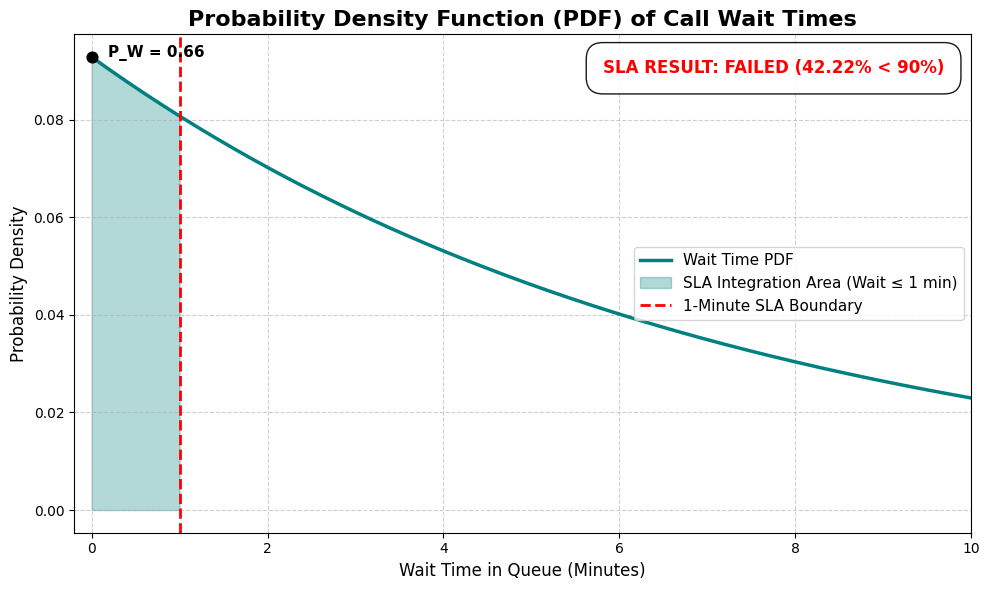

Plot successfully generated and saved as baseline_report_plot.png.


<Figure size 640x480 with 0 Axes>

In [31]:
# --- Assuming lambda_rate, mu_rate, current_agents, p_w, and max_wait_time are already loaded ---

# 1. Define a wider range of time points to make a nice, smooth curve
# We will plot from 0 to 10 minutes to see the probability drop off
t_plot_points = np.linspace(0, 10, 200)

# [ADDED FOR RESULTS] Generate time points strictly for the SLA condition (0 to 1 minute)
t_shade_points = np.linspace(0, max_wait_time, 100)

# 2. Calculate the PDF values using your custom function
pdf_plot_values = wait_time_pdf(t_plot_points, lambda_rate, mu_rate, current_agents, p_w)

# [ADDED FOR RESULTS] Calculate SLA shade values and the final integration percentage
pdf_shade_values = wait_time_pdf(t_shade_points, lambda_rate, mu_rate, current_agents, p_w)
p_no_wait = 1 - p_w
integral_portion = simpson(y=pdf_shade_values, x=t_shade_points)
total_success = (p_no_wait + integral_portion) * 100

# 3. Set up the visual canvas for the plot
plt.figure(figsize=(10, 6))

# 4. Plot the line
plt.plot(t_plot_points, pdf_plot_values, color='teal', linewidth=2.5, label='Wait Time PDF')

# 5. Fill the area under the curve for a more professional look 
# [MODIFIED FOR RESULTS] Only fill the area up to the 1-minute mark
plt.fill_between(t_shade_points, pdf_shade_values, alpha=0.3, color='teal', label='SLA Integration Area (Wait ≤ 1 min)')


# --- ADDED FOR RESULTS SECTION: Boundaries and Verdicts ---
# Add Vertical SLA Threshold Line
plt.axvline(x=max_wait_time, color='red', linestyle='--', linewidth=2, label='1-Minute SLA Boundary')

# Highlight starting P_w marker at t=0
net_speed = (current_agents * mu_rate - lambda_rate)
pw_height = p_w * net_speed
plt.scatter(0, pw_height, color='black', s=60, zorder=5)
plt.annotate(f'P_W = {p_w:.2f}', xy=(0, pw_height), xytext=(12, 0), textcoords='offset points', fontsize=11, fontweight='bold')

# Final Verdict Text Box
if total_success >= 90:
    verdict_text = f"SLA RESULT: PASSED ({total_success:.2f}% > 90%)"
    verdict_color = 'green'
else:
    verdict_text = f"SLA RESULT: FAILED ({total_success:.2f}% < 90%)"
    verdict_color = 'red'

props = dict(boxstyle='round,pad=1', facecolor='white', edgecolor='black', alpha=0.9)
plt.text(0.97, 0.95, verdict_text, transform=plt.gca().transAxes, fontsize=12, fontweight='bold', color=verdict_color, va='top', ha='right', bbox=props)
# ----------------------------------------------------------


# 6. Add titles, labels, and a grid to make the graph easy to read
plt.title('Probability Density Function (PDF) of Call Wait Times', fontsize=16, fontweight='bold')
plt.xlabel('Wait Time in Queue (Minutes)', fontsize=12)
# The y-axis shows the density (likelihood), not an exact percentage
plt.ylabel('Probability Density', fontsize=12) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11, loc='center right')
plt.xlim(-0.2, 10) # Lock the zoom to 10 minutes

# 7. Show the final graph
plt.tight_layout()
plt.savefig('baseline_mostafa_report_plot.png', dpi=300)
plt.show()
# 8. Save the final image
plt.savefig('baseline_report_plot.png', dpi=300)
print("Plot successfully generated and saved as baseline_report_plot.png.")
plt.show()